In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt 

import plotly.express as px
import plotly.subplots as sp

/Users/t4ng0_br4v0/anaconda3/lib/python3.11/site-packages/pandas/core/arrays/masked.py:61: UserWarning:

Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).



In [2]:
print(pd.__version__)

2.3.3


In [6]:
# Load the dataset
cars_df = sns.load_dataset('mpg')

# Quick preview
print(cars_df.shape)
cars_df.head()

(398, 9)


,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,name
0,18.0,8,307.0,130.0,3504,12.0,70,usa,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693,11.5,70,usa,buick skylark 320
2,18.0,8,318.0,150.0,3436,11.0,70,usa,plymouth satellite
3,16.0,8,304.0,150.0,3433,12.0,70,usa,amc rebel sst
4,17.0,8,302.0,140.0,3449,10.5,70,usa,ford torino


In [10]:
cars_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           398 non-null    float64
 1   cylinders     398 non-null    int64  
 2   displacement  398 non-null    float64
 3   horsepower    392 non-null    float64
 4   weight        398 non-null    int64  
 5   acceleration  398 non-null    float64
 6   model_year    398 non-null    int64  
 7   origin        398 non-null    object 
 8   name          398 non-null    object 
dtypes: float64(4), int64(3), object(2)
memory usage: 28.1+ KB


In [9]:
df = cars_df.copy()
df.head(3)

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,name
0,18.0,8,307.0,130.0,3504,12.0,70,usa,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693,11.5,70,usa,buick skylark 320
2,18.0,8,318.0,150.0,3436,11.0,70,usa,plymouth satellite


In [11]:
# # Automatically select all numerical cols from a df:
# numeric_cols = df.select_dtypes(include=np.number).columns

# # Set the max number of plots per row:
# max_cols = 3 # Adjust as needed, but keep space and visibility/readability in mind;

# # Calculate the number of rows needed based on the number of numeric columns:
# num_plots = len(numeric_cols)
# num_rows = int(np.ceil(num_plots / max_cols) ) # Ceiling division

# # Generate a list of colors; (one color per column)
# colors = sns.color_pal

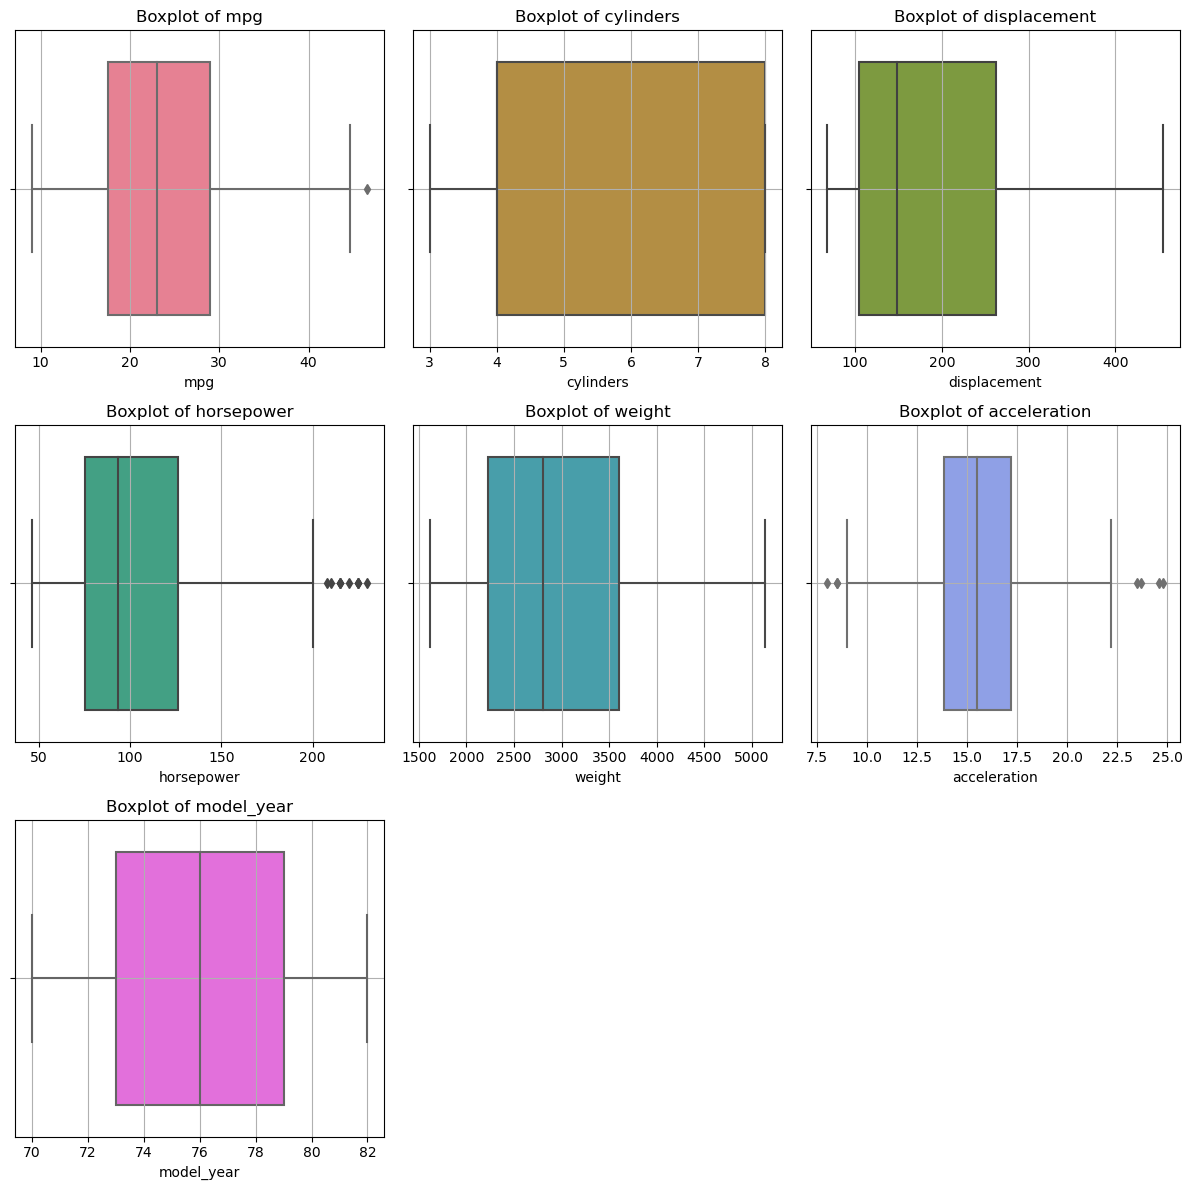

In [20]:
# NUMERIC COLS LOOP—BOXPLOT:

# Automatically select all numerical cols from a df:
numeric_cols = df.select_dtypes(include=np.number).columns

# Set the max number of plots per row:
max_cols = 3 # Adjust as needed, but keep space and visibility/readability in mind;

# Calculate the number of rows needed based on the number of numeric columns:
num_plots = len(numeric_cols)
num_rows = int(np.ceil(num_plots / max_cols) ) # Ceiling division

# Generate a list of colors; (one color per column)
colors = sns.color_palette("husl", num_plots) # Use Seaborn color palette for distinct colors;

# Create subplots with calculated rows and fixed columns:
fig, axes = plt.subplots(
    num_rows
    , max_cols
    , figsize=(max_cols * 4, num_rows * 4)
    , sharey=False # Adjust as needed; 
    )

# Flatten the axes array for easy iteration:
axes = axes.flatten()

# Loop through each numeric columns, colors and axes:
for i, (col, color) in enumerate(zip(numeric_cols, colors)):
    sns.boxplot(
        data=df
        , x=col # can manipulate the orientation by assignment of 'x' / 'y';
        , ax=axes[i]
        , color=color
#         , orient="h"
        )
    axes[i].set_title(f'Boxplot of {col}')
    axes[i].grid()
    
# Hide any unused axes (if num_plots < num_rows * max_cols):
for j in range(num_plots, len(axes)):
    fig.delaxes(axes[j])
    
# Adjust layout and display the plot(s):
plt.tight_layout()
plt.show();